# 04. Modelos conjuntos con identidad de empresa

**Autor:** Marco Padilla Gómez  
**Issue:** [#47](https://github.com/maarcoopg/tfg-ml-financial-sentiment/issues/47)  
**Rama:** `feature/per-company-temporal-evaluation`  
**Ejecución:** `ticker-aware-full-20260916`

## Pregunta

¿Podemos aprovechar los datos de las cuatro empresas sin obligar al modelo a tratarlas de la misma manera? Se estudian el identificador de empresa, las variables relativas y las interacciones empresa-variable.

Este es un **experimento nuevo**. No sobrescribe el entrenamiento independiente por empresa, su notebook ni los informes anteriores. El cuaderno lee resultados guardados: no entrena modelos ni descarga noticias.

## 1. Diseño del contraste

| Identificador | Qué cambia | Algoritmos |
| --- | --- | --- |
| `joint` | Conjunto original, sin identificador | Cinco |
| `individual` | Un entrenamiento por empresa, referencia anterior | Cinco |
| `raw_ticker` | Conjunto con tres indicadores binarios de empresa | Cinco |
| `relative_pooled` | Conjunto con variables relativas, sin identificador | Cinco |
| `relative_ticker` | Variables relativas e identificador de empresa | Cinco |
| `raw_interactions` | Variables originales, identificador e interacciones | Solo regresión logística |
| `relative_interactions` | Variables relativas, identificador e interacciones | Solo regresión logística |

Se prueban base, híbrido y retardo de una sesión en todos los enfoques. AAPL es la referencia de la codificación: MSFT, NVDA y TSLA tienen indicadores binarios propios. No se asigna un orden numérico artificial a las empresas ni se codifican a partir del objetivo.

En regresión logística, el identificador permite cambiar el nivel de partida de la probabilidad, pero no las pendientes. Multiplicar las variables por los indicadores permite pendientes distintas por empresa, conservando un ajuste conjunto regularizado. **No es un modelo bayesiano ni una estimación jerárquica explícita.** Los modelos de árboles ya pueden combinar el identificador y otras variables mediante sus divisiones; por eso la comprobación explícita de interacciones se limita a la regresión logística.

La comparación principal, fijada antes de observar estos resultados, es `relative_ticker` frente a `joint`, por algoritmo y variante.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src").is_dir() and (p / "reports").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.experiments.run_per_company import verify_pairing

RUN = ROOT / "reports/experiments/ticker-aware-full-20260916"
manifest = json.loads((RUN / "manifest.json").read_text(encoding="utf-8"))
assert manifest["status"] == "complete"
predictions = pd.read_csv(RUN / "predictions/all_predictions.csv", parse_dates=["Date"])
macro = pd.read_csv(RUN / "metrics/macro_metrics.csv")
companies = pd.read_csv(RUN / "metrics/company_metrics.csv")
all_metrics = pd.read_csv(RUN / "metrics/all_metrics.csv")
intervals = pd.read_csv(RUN / "metrics/paired_intervals.csv")
selection = pd.read_csv(RUN / "tuning/selected_params.csv")
coverage = pd.read_csv(RUN / "coverage/coverage_by_year_ticker.csv")

COMMON = ["joint", "individual", "raw_ticker", "relative_pooled", "relative_ticker"]
VARIANTS = ["base", "hybrid", "lag_1"]
COMPANIES = ["AAPL", "MSFT", "NVDA", "TSLA"]
LABELS = {"joint": "Conjunto original", "individual": "Individual",
          "raw_ticker": "Con empresa", "relative_pooled": "Relativas",
          "relative_ticker": "Relativas + empresa", "raw_interactions": "Interacciones originales",
          "relative_interactions": "Interacciones relativas",
          "base": "Base", "hybrid": "Híbrido", "lag_1": "Con retardo"}
MODELS = {"logistic_regression": "Regresión logística", "random_forest": "Bosque aleatorio",
          "hist_gradient_boosting": "Potenciación por histogramas", "xgboost": "XGBoost",
          "lightgbm": "LightGBM", "dummy": "Clase mayoritaria"}
pd.set_option("display.max_rows", 70)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
display(pd.DataFrame({"Dato": ["Estado", "Primera sesión externa", "Última sesión externa",
                               "Sesiones por empresa", "Verificación de la referencia"],
                      "Valor": [manifest["status"], str(predictions.Date.min().date()),
                                str(predictions.Date.max().date()), predictions.Date.nunique(),
                                "Entradas, panel, código, versiones y protocolo coincidentes"]}))

,Dato,Valor
0,Estado,complete
1,Primera sesión externa,2023-10-16
2,Última sesión externa,2025-12-29
3,Sesiones por empresa,553
4,Verificación de la referencia,"Entradas, panel, código, versiones y protocolo..."


## 2. Qué significa una comparación justa

Se mantienen las 553 sesiones externas por empresa, divididas en tres bloques, y las tres divisiones internas crecientes. La purga excluye etiquetas cuyo horizonte alcanza la validación o la prueba. El umbral sigue siendo 0,5 y las rejillas contienen dos configuraciones por algoritmo.

**La selección interna sigue utilizando AUC conjunto**, como en la referencia anterior. Para interpretar el resultado entre empresas usamos AUC macro: primero se calcula el AUC dentro de cada empresa y después se promedian las cuatro, con el mismo peso. Así no se confunde la separación de niveles de probabilidad entre empresas con una mejora de discriminación dentro de ellas.

Las referencias guardadas se reutilizan solo tras verificar datos de entrada, panel reconstruido, código principal, versiones, rejillas, predicciones y fronteras temporales. Las comprobaciones siguientes vuelven a verificar las observaciones y recalculan las métricas.

In [2]:
reference = predictions[predictions.approach == "joint"]
for approach, frame in predictions.groupby("approach"):
    matched = reference[reference.model_name.isin(frame.model_name.unique())]
    verify_pairing(frame, matched)
for (approach, variant, model, ticker), frame in predictions.groupby(
        ["approach", "dataset_type", "model_name", "ticker"]):
    expected = companies.loc[
        (companies.approach == approach) & (companies.dataset_type == variant)
        & (companies.model_name == model) & (companies.ticker == ticker), "roc_auc"].item()
    assert np.isclose(roc_auc_score(frame.target, frame.probability), expected, atol=1e-12)
checked = 0
for relative, digest in manifest["output_sha256"].items():
    path = ROOT / relative
    if path.is_relative_to(RUN):
        assert path.exists(), relative
        assert hashlib.sha256(path.read_bytes()).hexdigest() == digest, relative
        checked += 1
assert (pd.to_datetime(selection.train_target_end) < pd.to_datetime(selection.test_start)).all()
display(Markdown(f"**Verificados:** {checked} informes, {len(predictions):,} predicciones "
                 "y coincidencia de fechas, objetivos y bloques entre los enfoques."))

**Verificados:** 25 informes, 194,656 predicciones y coincidencia de fechas, objetivos y bloques entre los enfoques.

## 3. Variables originales y relativas

Las variables relativas reutilizan la transformación de la revisión anterior: distancia del cierre ajustado a las medias móviles, MACD dividido por el cierre ajustado y volumen frente a su media histórica. La base relativa contiene nueve variables financieras y **ninguna variable de noticias**.

El híbrido relativo contiene 22 variables: incorpora el número de noticias relativo a su media de las 20 sesiones anteriores y conserva los demás agregados de sentimiento existentes. No significa que todos los recuentos de noticias estén normalizados. El retardo relativo añade sentimiento medio y volumen relativo de noticias de la sesión anterior, alcanzando 24 variables.

Todas las medias históricas se calculan por empresa; las del volumen relativo excluyen la sesión actual. El sentimiento y las noticias siguen siendo específicos del activo. Un artículo compartido puede tener puntuaciones distintas para dos empresas. La cobertura y el instante de predicción no cambian.

In [3]:
feature_rows = [{"Enfoque": LABELS[approach], "Variante": LABELS[variant],
                 "Número de variables": len(columns)}
                for approach, variants in manifest["feature_sets"].items()
                for variant, columns in variants.items()]
display(pd.DataFrame(feature_rows).pivot(index="Enfoque", columns="Variante",
                                         values="Número de variables"))
display(Markdown("**Variables de la base relativa:**"))
display(pd.DataFrame({"Variable": manifest["feature_sets"]["relative_pooled"]["base"]}))
display(Markdown("**Cobertura registrada durante el histórico completo:**"))
news = coverage.groupby("ticker").agg(sesiones=("sessions", "sum"),
    sesiones_con_noticias=("recorded_news_days", "sum"), registros=("recorded_news", "sum"))
news["porcentaje_sesiones_con_noticias"] = 100 * news.sesiones_con_noticias / news.sesiones
display(news.round(2))

Variante,Base,Con retardo,Híbrido
Enfoque,,,
Con empresa,17,32,30
Interacciones originales,59,119,111
Interacciones relativas,39,99,91
Relativas,9,24,22
Relativas + empresa,12,27,25


**Variables de la base relativa:**

,Variable
0,daily_return
1,RSI
2,volatility_20
3,distance_sma_5
4,distance_sma_20
5,distance_sma_50
6,MACD_relative
7,MACD_signal_relative
8,Volume_relative


**Cobertura registrada durante el histórico completo:**

,sesiones,sesiones_con_noticias,registros,porcentaje_sesiones_con_noticias
ticker,,,,
AAPL,2764,2060,8895,74.53
MSFT,2764,2152,15250,77.86
NVDA,2764,1552,14709,56.15
TSLA,2764,1716,6916,62.08


## 4. Parámetros y fronteras temporales

Los parámetros se eligen dentro del pasado disponible para cada bloque. Se mantiene el mismo presupuesto de búsqueda: mejorar las variables no debe confundirse con ampliar el número de configuraciones probadas. Los modelos con interacciones tienen más variables y podrían requerir otra regularización, pero no se cambia la rejilla después de observar la prueba externa.

In [4]:
display(selection[["approach", "outer_fold", "train_rows", "test_rows", "train_end",
                   "train_target_end", "test_start", "test_end"]].drop_duplicates().reset_index(drop=True))
display(pd.DataFrame([{"Algoritmo": MODELS[m], "Configuración": i + 1,
                      "Parámetros": json.dumps(params, ensure_ascii=False)}
                     for m, configs in manifest["config"]["parameter_grids"].items()
                     for i, params in enumerate(configs)]))
display(Markdown("**Selecciones de regresión logística con interacciones:**"))
display(selection[selection.approach.str.endswith("interactions")][
    ["approach", "dataset_type", "outer_fold", "params", "inner_mean_auc"]].reset_index(drop=True))

,approach,outer_fold,train_rows,test_rows,train_end,train_target_end,test_start,test_end
0,raw_ticker,1,8840,740,2023-10-12,2023-10-13,2023-10-16,2024-07-11
1,raw_ticker,2,9580,736,2024-07-10,2024-07-11,2024-07-12,2025-04-04
2,raw_ticker,3,10316,736,2025-04-03,2025-04-04,2025-04-07,2025-12-29
3,relative_pooled,1,8840,740,2023-10-12,2023-10-13,2023-10-16,2024-07-11
4,relative_pooled,2,9580,736,2024-07-10,2024-07-11,2024-07-12,2025-04-04
5,relative_pooled,3,10316,736,2025-04-03,2025-04-04,2025-04-07,2025-12-29
6,relative_ticker,1,8840,740,2023-10-12,2023-10-13,2023-10-16,2024-07-11
7,relative_ticker,2,9580,736,2024-07-10,2024-07-11,2024-07-12,2025-04-04
8,relative_ticker,3,10316,736,2025-04-03,2025-04-04,2025-04-07,2025-12-29
9,raw_interactions,1,8840,740,2023-10-12,2023-10-13,2023-10-16,2024-07-11


,Algoritmo,Configuración,Parámetros
0,Regresión logística,1,"{""model__C"": 0.1}"
1,Regresión logística,2,"{""model__C"": 10.0}"
2,Bosque aleatorio,1,"{""model__n_estimators"": 100, ""model__max_depth..."
3,Bosque aleatorio,2,"{""model__n_estimators"": 100, ""model__max_depth..."
4,Potenciación por histogramas,1,"{""model__max_iter"": 100, ""model__max_leaf_node..."
5,Potenciación por histogramas,2,"{""model__max_iter"": 100, ""model__max_leaf_node..."
6,XGBoost,1,"{""model__n_estimators"": 100, ""model__max_depth..."
7,XGBoost,2,"{""model__n_estimators"": 100, ""model__max_depth..."
8,LightGBM,1,"{""model__n_estimators"": 100, ""model__num_leave..."
9,LightGBM,2,"{""model__n_estimators"": 100, ""model__num_leave..."


**Selecciones de regresión logística con interacciones:**

,approach,dataset_type,outer_fold,params,inner_mean_auc
0,raw_interactions,base,1,{},0.500000
1,raw_interactions,base,1,"{""model__C"": 10.0}",0.511781
2,raw_interactions,hybrid,1,"{""model__C"": 10.0}",0.512012
3,raw_interactions,lag_1,1,"{""model__C"": 10.0}",0.510806
4,raw_interactions,base,2,{},0.500000
5,raw_interactions,base,2,"{""model__C"": 0.1}",0.511728
6,raw_interactions,hybrid,2,"{""model__C"": 10.0}",0.510745
7,raw_interactions,lag_1,2,"{""model__C"": 10.0}",0.511223
8,raw_interactions,base,3,{},0.500000
9,raw_interactions,base,3,"{""model__C"": 10.0}",0.504830


## 5. Resultados de todos los algoritmos

La tabla muestra el AUC macro de cada combinación. No se mezclan máximos de algoritmos diferentes. El enfoque individual de referencia mantiene el mismo algoritmo y variante, pero ajusta un modelo por empresa.

La segunda tabla promedia los cinco algoritmos únicamente para resumir el patrón general. **Ese promedio no es el rendimiento de un modelo adicional** ni de una combinación de predicciones. Las interacciones explícitas se analizan aparte para no promediar conjuntos de algoritmos distintos.

In [5]:
learned = macro[macro.model_name != "dummy"]
table = learned[learned.approach.isin(COMMON)].pivot(
    index=["dataset_type", "model_name"], columns="approach", values="roc_auc").reindex(columns=COMMON)
table.index = pd.MultiIndex.from_tuples([(LABELS[v], MODELS[m]) for v, m in table.index],
                                       names=["Variante", "Algoritmo"])
display(table.rename(columns=LABELS).round(4))
overview = learned[learned.approach.isin(COMMON)].groupby(
    ["dataset_type", "approach"]).roc_auc.mean().unstack("approach").reindex(index=VARIANTS, columns=COMMON)
display(Markdown("**Resumen descriptivo: media de los cinco algoritmos y cuatro empresas.**"))
display(overview.rename(index=LABELS, columns=LABELS).round(4))

approach                                  Conjunto original  Individual  \
Variante    Algoritmo                                                     
Base        Potenciación por histogramas             0.4846      0.4965   
            LightGBM                                 0.4899      0.4972   
            Regresión logística                      0.5015      0.4839   
            Bosque aleatorio                         0.5057      0.4884   
            XGBoost                                  0.4918      0.4992   
Híbrido     Potenciación por histogramas             0.4961      0.5000   
            LightGBM                                 0.4938      0.4929   
            Regresión logística                      0.4987      0.4934   
            Bosque aleatorio                         0.5054      0.4944   
            XGBoost                                  0.4988      0.5016   
Con retardo Potenciación por histogramas             0.4934      0.4960   
            LightGBM                                 0.4950      0.5028   
            Regresión logística                      0.4961      0.4968   
            Bosque aleatorio                         0.5091      0.4911   
            XGBoost                                  0.4996      0.4978   

approach                                  Con empresa  Relativas  \
Variante    Algoritmo                                              
Base        Potenciación por histogramas       0.4917     0.5030   
            LightGBM                           0.4935     0.4983   
            Regresión logística                0.4981     0.5019   
            Bosque aleatorio                   0.4956     0.5068   
            XGBoost                            0.4948     0.5054   
Híbrido     Potenciación por histogramas       0.4937     0.5127   
            LightGBM                           0.4967     0.5000   
            Regresión logística                0.4964     0.5000   
            Bosque aleatorio                   0.5074     0.5112   
            XGBoost                            0.4980     0.5079   
Con retardo Potenciación por histogramas       0.4935     0.5024   
            LightGBM                           0.4963     0.5121   
            Regresión logística                0.4942     0.4998   
            Bosque aleatorio                   0.5046     0.5099   
            XGBoost                            0.5061     0.5049   

approach                                  Relativas + empresa  
Variante    Algoritmo                                          
Base        Potenciación por histogramas               0.5011  
            LightGBM                                   0.5029  
            Regresión logística                        0.5010  
            Bosque aleatorio                           0.4990  
            XGBoost                                    0.5008  
Híbrido     Potenciación por histogramas               0.5029  
            LightGBM                                   0.5103  
            Regresión logística                        0.4980  
            Bosque aleatorio                           0.5139  
            XGBoost                                    0.5095  
Con retardo Potenciación por histogramas               0.4993  
            LightGBM                                   0.4972  
            Regresión logística                        0.4981  
            Bosque aleatorio                           0.5157  
            XGBoost                                    0.5082

**Resumen descriptivo: media de los cinco algoritmos y cuatro empresas.**

approach,Conjunto original,Individual,Con empresa,Relativas,Relativas + empresa
dataset_type,,,,,
Base,0.4947,0.4930,0.4947,0.5031,0.5010
Híbrido,0.4986,0.4964,0.4984,0.5064,0.5069
Con retardo,0.4986,0.4969,0.4989,0.5058,0.5037


## 6. Comparación principal e incertidumbre

Se remuestrean 1.000 secuencias de bloques de 20 sesiones, usando las mismas fechas para los dos enfoques y para las cuatro empresas. En cada réplica se calcula el AUC por empresa y después su promedio macro. La versión por multiplicidades evita repetir ordenaciones y está contrastada mediante pruebas contra el cálculo de AUC de scikit-learn y el procedimiento anterior.

La diferencia es **relativas con empresa menos conjunto original**, manteniendo algoritmo y variante. Si el intervalo del 95 % incluye cero, la diferencia no queda claramente distinguida de cero con este procedimiento. No hay corrección por comparaciones múltiples y el remuestreo no vuelve a entrenar modelos.

Esta evaluación sigue usando fechas históricas previamente examinadas. Los intervalos describen incertidumbre de las predicciones guardadas; no convierten esta exploración en una nueva validación final.

,dataset_type,model_name,roc_auc,reference_auc,auc_delta,delta_low,delta_high
229,base,hist_gradient_boosting,0.50107,0.48463,0.01644,-0.00955,0.03943
234,base,lightgbm,0.50293,0.48992,0.01301,-0.01390,0.03800
239,base,logistic_regression,0.50098,0.50154,-0.00055,-0.01482,0.01121
244,base,random_forest,0.49903,0.50571,-0.00668,-0.03262,0.02187
249,base,xgboost,0.50079,0.49181,0.00898,-0.01559,0.03923
254,hybrid,hist_gradient_boosting,0.50295,0.49612,0.00682,-0.01753,0.03233
259,hybrid,lightgbm,0.51033,0.49380,0.01652,-0.01038,0.04123
264,hybrid,logistic_regression,0.49804,0.49871,-0.00068,-0.00827,0.00757
269,hybrid,random_forest,0.51387,0.50536,0.00851,-0.01408,0.03274
274,hybrid,xgboost,0.50945,0.49883,0.01062,-0.00911,0.03355


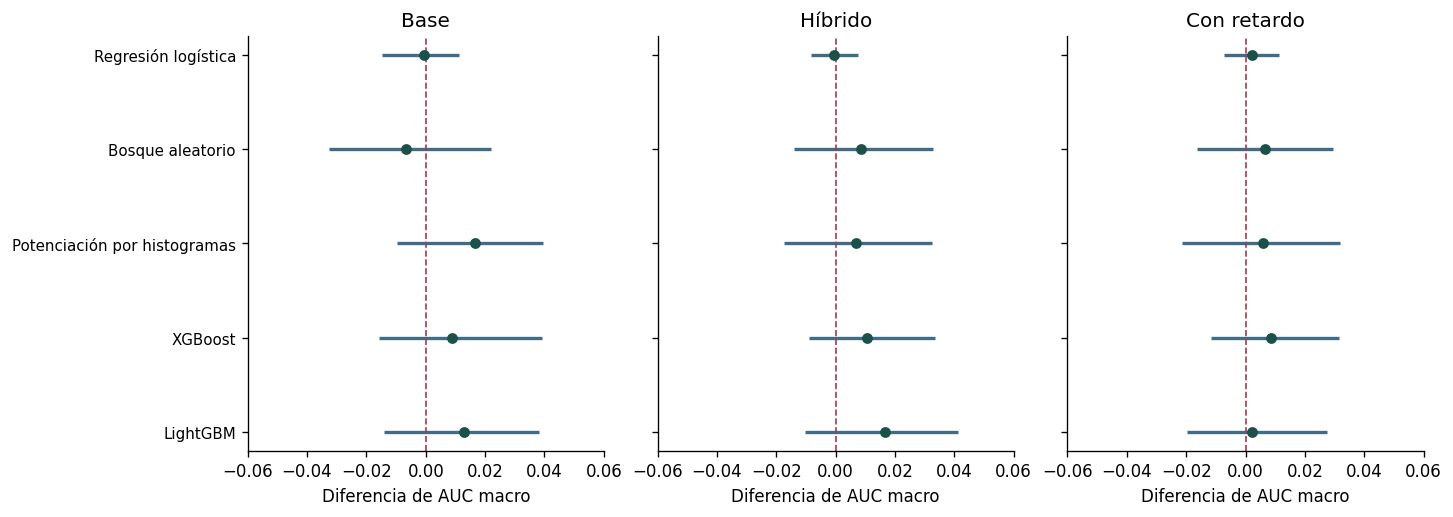

De 15 comparaciones principales, 12 tienen diferencia observada positiva; 0 intervalos quedan por encima de cero y 0 por debajo.

In [6]:
primary = intervals[(intervals.approach == "relative_ticker")
                    & (intervals.reference == "joint") & (intervals.ticker == "macro")].copy()
display(primary[["dataset_type", "model_name", "roc_auc", "reference_auc", "auc_delta",
                 "delta_low", "delta_high"]].round(5))
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained", sharex=True, sharey=True)
order = list(MODELS)[:-1]
limit = max(0.06, float(primary[["delta_low", "delta_high"]].abs().max().max()) * 1.15)
for variant, ax in zip(VARIANTS, axes):
    data = primary[primary.dataset_type == variant].set_index("model_name").reindex(order)
    y = np.arange(len(data))
    ax.hlines(y, data.delta_low, data.delta_high, color="#426b86", linewidth=2)
    ax.scatter(data.auc_delta, y, color="#1b5149", s=30, zorder=3)
    ax.axvline(0, color="#a23c51", linestyle="--", linewidth=1)
    ax.set(title=LABELS[variant], xlabel="Diferencia de AUC macro", xlim=(-limit, limit))
    ax.set_yticks(y, [MODELS[m] for m in order], fontsize=9)
axes[0].invert_yaxis()
plt.show()
display(Markdown(f"De {len(primary)} comparaciones principales, "
    f"{int((primary.auc_delta > 0).sum())} tienen diferencia observada positiva; "
    f"{int((primary.delta_low > 0).sum())} intervalos quedan por encima de cero y "
    f"{int((primary.delta_high < 0).sum())} por debajo."))

## 7. ¿Qué modificación explica la diferencia?

Los contrastes adicionales separan efectos: identificador con variables originales, cambio a variables relativas sin identificador, identificador sobre variables relativas y combinación frente al entrenamiento individual anterior. Las interacciones explícitas se reservan para el apartado siguiente.

Se muestran todas las diferencias macro, no solo las favorables. Las comparaciones entre variantes de noticias que puedan apreciarse en las tablas no deben confundirse con estos contrastes entre enfoques.

In [7]:
comparisons = [
    ("raw_ticker", "joint", "Añadir identificador a variables originales"),
    ("relative_pooled", "joint", "Cambiar a variables relativas"),
    ("relative_ticker", "relative_pooled", "Añadir identificador a variables relativas"),
    ("relative_ticker", "individual", "Comparar con modelos individuales"),
]
for candidate, baseline, title in comparisons:
    display(Markdown(f"### {title}"))
    data = intervals[(intervals.approach == candidate) & (intervals.reference == baseline)
                     & (intervals.ticker == "macro")]
    display(data[["dataset_type", "model_name", "auc_delta", "delta_low", "delta_high"]].round(5))

### Añadir identificador a variables originales

,dataset_type,model_name,auc_delta,delta_low,delta_high
4,base,hist_gradient_boosting,0.00709,-0.00321,0.01764
9,base,lightgbm,0.00353,-0.01197,0.01683
14,base,logistic_regression,-0.00346,-0.01135,0.00492
19,base,random_forest,-0.01012,-0.02356,0.00597
24,base,xgboost,0.00294,-0.00803,0.01209
29,hybrid,hist_gradient_boosting,-0.00244,-0.01346,0.00613
34,hybrid,lightgbm,0.00291,-0.01307,0.01901
39,hybrid,logistic_regression,-0.00235,-0.00663,0.00226
44,hybrid,random_forest,0.00201,-0.01012,0.01423
49,hybrid,xgboost,-0.00085,-0.01038,0.00932


### Cambiar a variables relativas

,dataset_type,model_name,auc_delta,delta_low,delta_high
79,base,hist_gradient_boosting,0.01837,-0.00943,0.04191
84,base,lightgbm,0.00840,-0.01976,0.03783
89,base,logistic_regression,0.00037,-0.01333,0.01190
94,base,random_forest,0.00109,-0.02678,0.03092
99,base,xgboost,0.01361,-0.00958,0.03891
104,hybrid,hist_gradient_boosting,0.01660,-0.01132,0.04419
109,hybrid,lightgbm,0.00619,-0.01795,0.03627
114,hybrid,logistic_regression,0.00131,-0.00792,0.00921
119,hybrid,random_forest,0.00588,-0.01342,0.03045
124,hybrid,xgboost,0.00911,-0.01223,0.03226


### Añadir identificador a variables relativas

,dataset_type,model_name,auc_delta,delta_low,delta_high
154,base,hist_gradient_boosting,-0.00193,-0.01359,0.00908
159,base,lightgbm,0.00462,-0.00872,0.01565
164,base,logistic_regression,-0.00093,-0.00416,0.00165
169,base,random_forest,-0.00777,-0.02336,0.00612
174,base,xgboost,-0.00463,-0.01715,0.00873
179,hybrid,hist_gradient_boosting,-0.00978,-0.02197,0.00380
184,hybrid,lightgbm,0.01033,-0.00958,0.02153
189,hybrid,logistic_regression,-0.00199,-0.00399,0.00176
194,hybrid,random_forest,0.00263,-0.01175,0.01625
199,hybrid,xgboost,0.00151,-0.01133,0.01533


### Comparar con modelos individuales

,dataset_type,model_name,auc_delta,delta_low,delta_high
334,base,hist_gradient_boosting,0.00454,-0.02478,0.03373
339,base,lightgbm,0.00573,-0.02527,0.03527
344,base,logistic_regression,0.01713,-0.00845,0.04015
349,base,random_forest,0.01059,-0.02366,0.04534
354,base,xgboost,0.00157,-0.02993,0.03517
359,hybrid,hist_gradient_boosting,0.00299,-0.03055,0.04154
364,hybrid,lightgbm,0.01741,-0.01669,0.04853
369,hybrid,logistic_regression,0.00468,-0.01791,0.02789
374,hybrid,random_forest,0.01949,-0.01120,0.04949
379,hybrid,xgboost,0.00785,-0.02082,0.03931


## 8. Resultados dentro de cada empresa

Una mejora macro podría ocultar empeoramientos de un activo. Estas tablas conservan las cuatro empresas y todos los algoritmos. El gráfico muestra la diferencia entre relativas con empresa y conjunto original, con la misma escala para todos los paneles. El color representa una diferencia observada, no significación estadística.

### AAPL

approach                             Conjunto original  Individual  \
dataset_type model_name                                              
base         hist_gradient_boosting             0.4619      0.4512   
             lightgbm                           0.4746      0.4632   
             logistic_regression                0.4495      0.4270   
             random_forest                      0.5292      0.4413   
             xgboost                            0.4586      0.4663   
hybrid       hist_gradient_boosting             0.4707      0.4709   
             lightgbm                           0.4873      0.4355   
             logistic_regression                0.4688      0.4458   
             random_forest                      0.4926      0.4414   
             xgboost                            0.4802      0.4507   
lag_1        hist_gradient_boosting             0.4851      0.4702   
             lightgbm                           0.4825      0.4668   
             logistic_regression                0.4694      0.4536   
             random_forest                      0.4947      0.4411   
             xgboost                            0.4883      0.4639   

approach                             Con empresa  Relativas  \
dataset_type model_name                                       
base         hist_gradient_boosting       0.4660     0.4573   
             lightgbm                     0.4887     0.4582   
             logistic_regression          0.4511     0.4504   
             random_forest                0.4820     0.4632   
             xgboost                      0.4694     0.4539   
hybrid       hist_gradient_boosting       0.4710     0.4956   
             lightgbm                     0.4840     0.4782   
             logistic_regression          0.4637     0.4662   
             random_forest                0.4891     0.4595   
             xgboost                      0.4810     0.4655   
lag_1        hist_gradient_boosting       0.4837     0.4858   
             lightgbm                     0.4711     0.4779   
             logistic_regression          0.4622     0.4661   
             random_forest                0.4972     0.4537   
             xgboost                      0.5010     0.4462   

approach                             Relativas + empresa  
dataset_type model_name                                   
base         hist_gradient_boosting               0.4522  
             lightgbm                             0.4732  
             logistic_regression                  0.4503  
             random_forest                        0.4423  
             xgboost                              0.4636  
hybrid       hist_gradient_boosting               0.4694  
             lightgbm                             0.4629  
             logistic_regression                  0.4640  
             random_forest                        0.4645  
             xgboost                              0.4566  
lag_1        hist_gradient_boosting               0.4732  
             lightgbm                             0.4572  
             logistic_regression                  0.4633  
             random_forest                        0.4836  
             xgboost                              0.4547

### MSFT

approach                             Conjunto original  Individual  \
dataset_type model_name                                              
base         hist_gradient_boosting             0.4891      0.5141   
             lightgbm                           0.4775      0.5097   
             logistic_regression                0.5220      0.4945   
             random_forest                      0.4889      0.5058   
             xgboost                            0.5048      0.4923   
hybrid       hist_gradient_boosting             0.4883      0.5123   
             lightgbm                           0.4862      0.5028   
             logistic_regression                0.5039      0.4939   
             random_forest                      0.4852      0.5069   
             xgboost                            0.5034      0.4948   
lag_1        hist_gradient_boosting             0.4757      0.4996   
             lightgbm                           0.4803      0.5075   
             logistic_regression                0.4949      0.4946   
             random_forest                      0.4865      0.5024   
             xgboost                            0.4976      0.4941   

approach                             Con empresa  Relativas  \
dataset_type model_name                                       
base         hist_gradient_boosting       0.4910     0.5098   
             lightgbm                     0.4887     0.4828   
             logistic_regression          0.5001     0.5207   
             random_forest                0.4906     0.4945   
             xgboost                      0.5009     0.5116   
hybrid       hist_gradient_boosting       0.4778     0.5070   
             lightgbm                     0.4728     0.4998   
             logistic_regression          0.5009     0.5072   
             random_forest                0.4881     0.5073   
             xgboost                      0.4944     0.5041   
lag_1        hist_gradient_boosting       0.4821     0.4899   
             lightgbm                     0.4788     0.5265   
             logistic_regression          0.4965     0.5078   
             random_forest                0.4953     0.5048   
             xgboost                      0.5004     0.5051   

approach                             Relativas + empresa  
dataset_type model_name                                   
base         hist_gradient_boosting               0.4984  
             lightgbm                             0.4836  
             logistic_regression                  0.5181  
             random_forest                        0.4837  
             xgboost                              0.4865  
hybrid       hist_gradient_boosting               0.5015  
             lightgbm                             0.5194  
             logistic_regression                  0.5034  
             random_forest                        0.5047  
             xgboost                              0.5083  
lag_1        hist_gradient_boosting               0.5095  
             lightgbm                             0.4886  
             logistic_regression                  0.5043  
             random_forest                        0.5081  
             xgboost                              0.5042

### NVDA

approach                             Conjunto original  Individual  \
dataset_type model_name                                              
base         hist_gradient_boosting             0.4742      0.5224   
             lightgbm                           0.4921      0.5106   
             logistic_regression                0.5180      0.4879   
             random_forest                      0.4875      0.4970   
             xgboost                            0.4899      0.5190   
hybrid       hist_gradient_boosting             0.4837      0.5048   
             lightgbm                           0.4940      0.5112   
             logistic_regression                0.5189      0.5110   
             random_forest                      0.5180      0.5026   
             xgboost                            0.4920      0.5304   
lag_1        hist_gradient_boosting             0.4956      0.5193   
             lightgbm                           0.5188      0.5158   
             logistic_regression                0.5192      0.5067   
             random_forest                      0.5309      0.5012   
             xgboost                            0.5035      0.5242   

approach                             Con empresa  Relativas  \
dataset_type model_name                                       
base         hist_gradient_boosting       0.4768     0.5419   
             lightgbm                     0.4737     0.5467   
             logistic_regression          0.5145     0.5134   
             random_forest                0.4867     0.5473   
             xgboost                      0.4943     0.5412   
hybrid       hist_gradient_boosting       0.4932     0.5493   
             lightgbm                     0.5042     0.5284   
             logistic_regression          0.5146     0.5183   
             random_forest                0.5132     0.5711   
             xgboost                      0.5000     0.5512   
lag_1        hist_gradient_boosting       0.4912     0.5408   
             lightgbm                     0.5189     0.5350   
             logistic_regression          0.5134     0.5171   
             random_forest                0.5086     0.5547   
             xgboost                      0.5075     0.5453   

approach                             Relativas + empresa  
dataset_type model_name                                   
base         hist_gradient_boosting               0.5510  
             lightgbm                             0.5566  
             logistic_regression                  0.5121  
             random_forest                        0.5525  
             xgboost                              0.5478  
hybrid       hist_gradient_boosting               0.5487  
             lightgbm                             0.5547  
             logistic_regression                  0.5140  
             random_forest                        0.5717  
             xgboost                              0.5511  
lag_1        hist_gradient_boosting               0.5134  
             lightgbm                             0.5542  
             logistic_regression                  0.5142  
             random_forest                        0.5500  
             xgboost                              0.5413

### TSLA

approach                             Conjunto original  Individual  \
dataset_type model_name                                              
base         hist_gradient_boosting             0.5133      0.4984   
             lightgbm                           0.5155      0.5052   
             logistic_regression                0.5167      0.5260   
             random_forest                      0.5173      0.5097   
             xgboost                            0.5139      0.5193   
hybrid       hist_gradient_boosting             0.5418      0.5118   
             lightgbm                           0.5078      0.5221   
             logistic_regression                0.5033      0.5227   
             random_forest                      0.5256      0.5267   
             xgboost                            0.5198      0.5304   
lag_1        hist_gradient_boosting             0.5173      0.4949   
             lightgbm                           0.4984      0.5210   
             logistic_regression                0.5008      0.5324   
             random_forest                      0.5242      0.5196   
             xgboost                            0.5089      0.5088   

approach                             Con empresa  Relativas  \
dataset_type model_name                                       
base         hist_gradient_boosting       0.5331     0.5030   
             lightgbm                     0.5227     0.5056   
             logistic_regression          0.5266     0.5232   
             random_forest                0.5230     0.5222   
             xgboost                      0.5143     0.5149   
hybrid       hist_gradient_boosting       0.5327     0.4989   
             lightgbm                     0.5258     0.4936   
             logistic_regression          0.5063     0.5084   
             random_forest                0.5391     0.5070   
             xgboost                      0.5165     0.5109   
lag_1        hist_gradient_boosting       0.5171     0.4931   
             lightgbm                     0.5164     0.5091   
             logistic_regression          0.5045     0.5082   
             random_forest                0.5172     0.5265   
             xgboost                      0.5156     0.5230   

approach                             Relativas + empresa  
dataset_type model_name                                   
base         hist_gradient_boosting               0.5028  
             lightgbm                             0.4983  
             logistic_regression                  0.5235  
             random_forest                        0.5176  
             xgboost                              0.5053  
hybrid       hist_gradient_boosting               0.4921  
             lightgbm                             0.5043  
             logistic_regression                  0.5106  
             random_forest                        0.5146  
             xgboost                              0.5218  
lag_1        hist_gradient_boosting               0.5012  
             lightgbm                             0.4888  
             logistic_regression                  0.5105  
             random_forest                        0.5211  
             xgboost                              0.5324

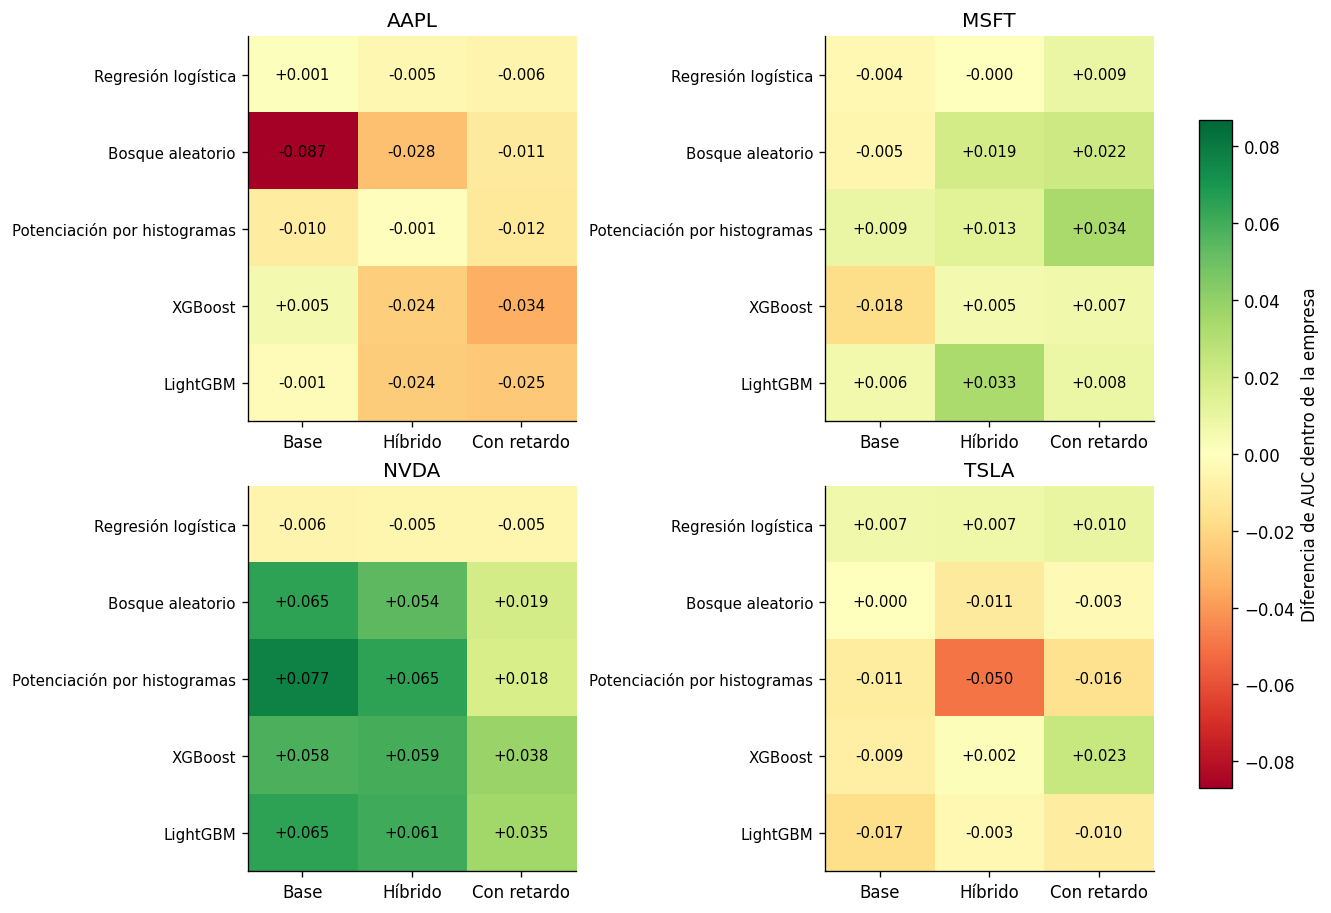

In [8]:
for ticker in COMPANIES:
    table = companies[(companies.ticker == ticker) & companies.approach.isin(COMMON)
                      & (companies.model_name != "dummy")].pivot(
        index=["dataset_type", "model_name"], columns="approach", values="roc_auc").reindex(columns=COMMON)
    display(Markdown(f"### {ticker}"))
    display(table.rename(columns=LABELS).round(4))
company_delta = intervals[(intervals.approach == "relative_ticker")
                          & (intervals.reference == "joint") & (intervals.ticker != "macro")]
scale = max(0.02, float(company_delta.auc_delta.abs().max()))
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), layout="constrained")
for ticker, ax in zip(COMPANIES, axes.flat):
    data = company_delta[company_delta.ticker == ticker].pivot(
        index="model_name", columns="dataset_type", values="auc_delta").reindex(index=order, columns=VARIANTS)
    im = ax.imshow(data, cmap="RdYlGn", vmin=-scale, vmax=scale, aspect="auto")
    ax.set_xticks(range(3), [LABELS[v] for v in VARIANTS])
    ax.set_yticks(range(5), [MODELS[m] for m in order], fontsize=9)
    ax.set_title(ticker)
    for i in range(5):
        for j in range(3):
            ax.text(j, i, f"{data.iloc[i, j]:+.3f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=axes.ravel().tolist(), label="Diferencia de AUC dentro de la empresa", shrink=0.8)
plt.show()

## 9. Interacciones explícitas en regresión logística

Aquí solo se compara regresión logística con regresión logística. El modelo con interacciones puede cambiar tanto su nivel de partida como la respuesta a cada variable según la empresa. AAPL es la categoría de referencia; la regularización penaliza los coeficientes de interacción, pero no se estima una estructura jerárquica separada.

Se contrasta cada modelo con interacciones frente a su versión con identificador y las mismas variables originales o relativas. No se compara una media de un solo algoritmo con la media de los otros cinco.

approach,Individual,Conjunto original,Interacciones originales,Con empresa,Interacciones relativas,Relativas,Relativas + empresa
dataset_type,,,,,,,
Base,0.4839,0.5015,0.4887,0.4981,0.4978,0.5019,0.5010
Híbrido,0.4934,0.4987,0.4978,0.4964,0.5059,0.5000,0.4980
Con retardo,0.4968,0.4961,0.4987,0.4942,0.5076,0.4998,0.4981


,approach,reference,dataset_type,auc_delta,delta_low,delta_high
304,raw_interactions,raw_ticker,base,-0.00933,-0.03259,0.01027
309,raw_interactions,raw_ticker,hybrid,0.00139,-0.02349,0.02754
314,raw_interactions,raw_ticker,lag_1,0.00450,-0.02015,0.02855
319,relative_interactions,relative_ticker,base,-0.00313,-0.01990,0.01329
324,relative_interactions,relative_ticker,hybrid,0.00785,-0.01150,0.02784
329,relative_interactions,relative_ticker,lag_1,0.00948,-0.00986,0.02810


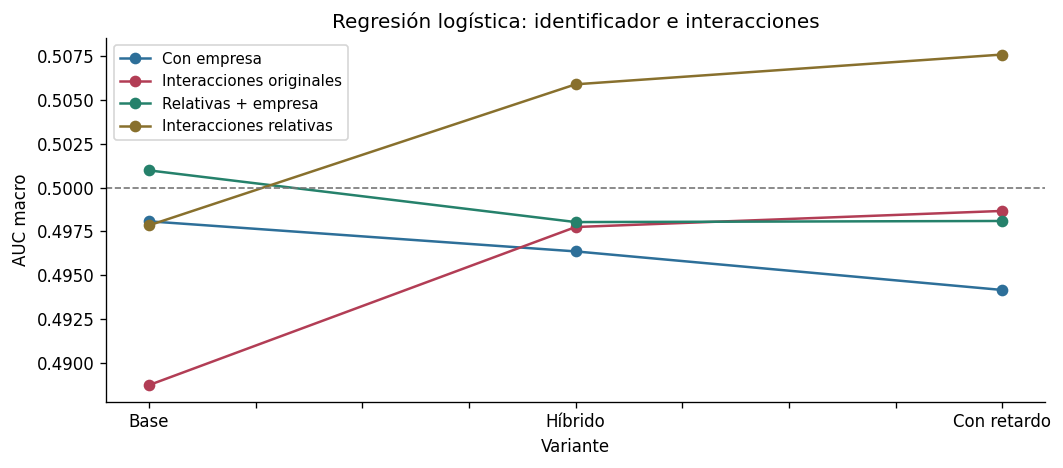

In [9]:
logistic = learned[learned.model_name == "logistic_regression"].pivot(
    index="dataset_type", columns="approach", values="roc_auc").reindex(index=VARIANTS)
display(logistic.rename(index=LABELS, columns=LABELS).round(4))
interaction_intervals = intervals[intervals.approach.str.endswith("interactions")
                                 & (intervals.ticker == "macro")]
display(interaction_intervals[["approach", "reference", "dataset_type", "auc_delta",
                              "delta_low", "delta_high"]].round(5))
ax = logistic[["raw_ticker", "raw_interactions", "relative_ticker", "relative_interactions"]].rename(
    index=LABELS, columns=LABELS).plot(marker="o", figsize=(9, 4),
        color=["#2d6f99", "#b23d55", "#25816b", "#88702d"])
ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
ax.set(xlabel="Variante", ylabel="AUC macro", title="Regresión logística: identificador e interacciones")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## 10. Exactitud, equilibrio y estabilidad por bloque

AUC no es porcentaje de aciertos. La exactitud equilibrada y MCC ayudan a interpretar las clases predichas con umbral fijo. La referencia mayoritaria puede tener una exactitud superior a 0,5 sin discriminar subidas y bajadas.

También se distingue el AUC macro de todas las predicciones externas del promedio de AUC de los bloques. Los modelos cambian entre bloques y sus probabilidades pueden tener calibraciones distintas.

In [10]:
display(macro[(macro.approach == "relative_ticker")][
    ["dataset_type", "model_name", "roc_auc", "mean_outer_auc", "accuracy",
     "balanced_accuracy", "f1_macro", "mcc"]].round(4))
folds = all_metrics[(all_metrics.scope == "outer_fold")
                   & all_metrics.approach.isin(["joint", "relative_ticker"])
                   & (all_metrics.model_name != "dummy")]
display(folds.groupby(["approach", "dataset_type", "model_name", "group"]).roc_auc.mean().unstack("group").round(4))
display(Markdown("**Referencia de clase mayoritaria por empresa:**"))
display(companies[(companies.approach == "joint") & (companies.model_name == "dummy")][
    ["ticker", "accuracy", "balanced_accuracy", "roc_auc", "mcc"]].round(4))

,dataset_type,model_name,roc_auc,mean_outer_auc,accuracy,balanced_accuracy,f1_macro,mcc
72,base,dummy,0.5000,0.5000,0.5389,0.5000,0.3501,0.0000
73,base,hist_gradient_boosting,0.5011,0.5032,0.5249,0.5002,0.4625,0.0009
74,base,lightgbm,0.5029,0.5015,0.5244,0.4998,0.4625,-0.0004
75,base,logistic_regression,0.5010,0.5054,0.5353,0.4991,0.3927,-0.0049
76,base,random_forest,0.4990,0.5005,0.5371,0.5035,0.4132,0.0158
77,base,xgboost,0.5008,0.5028,0.5285,0.4979,0.4296,-0.0102
78,hybrid,hist_gradient_boosting,0.5029,0.5025,0.5095,0.4941,0.4782,-0.0152
79,hybrid,lightgbm,0.5103,0.5122,0.5176,0.5056,0.4962,0.0100
80,hybrid,logistic_regression,0.4980,0.5044,0.5045,0.4983,0.4942,-0.0042
81,hybrid,random_forest,0.5139,0.5193,0.5217,0.5051,0.4857,0.0088


group                                                   1.0     2.0     3.0
approach        dataset_type model_name                                    
joint           base         hist_gradient_boosting  0.4593  0.5055  0.5206
                             lightgbm                0.4659  0.5217  0.5130
                             logistic_regression     0.4990  0.5121  0.4951
                             random_forest           0.4818  0.5559  0.5264
                             xgboost                 0.4711  0.5271  0.5253
                hybrid       hist_gradient_boosting  0.5047  0.5046  0.5162
                             lightgbm                0.4736  0.5202  0.5027
                             logistic_regression     0.5051  0.4938  0.5091
                             random_forest           0.5037  0.5275  0.5168
                             xgboost                 0.4996  0.5114  0.5163
                lag_1        hist_gradient_boosting  0.4869  0.5075  0.5114
                             lightgbm                0.4872  0.5088  0.5095
                             logistic_regression     0.4922  0.4948  0.5105
                             random_forest           0.5143  0.5217  0.5160
                             xgboost                 0.4998  0.5133  0.5152
relative_ticker base         hist_gradient_boosting  0.4874  0.5112  0.5108
                             lightgbm                0.4784  0.5207  0.5054
                             logistic_regression     0.4951  0.5109  0.5100
                             random_forest           0.4635  0.5311  0.5068
                             xgboost                 0.4636  0.5215  0.5232
                hybrid       hist_gradient_boosting  0.5041  0.5132  0.4901
                             lightgbm                0.5133  0.5040  0.5194
                             logistic_regression     0.5050  0.4947  0.5136
                             random_forest           0.5143  0.5023  0.5414
                             xgboost                 0.4904  0.5209  0.5161
                lag_1        hist_gradient_boosting  0.4868  0.5231  0.4869
                             lightgbm                0.4839  0.5027  0.5165
                             logistic_regression     0.5049  0.4944  0.5142
                             random_forest           0.5182  0.5009  0.5360
                             xgboost                 0.4935  0.5160  0.5178

**Referencia de clase mayoritaria por empresa:**

,ticker,accuracy,balanced_accuracy,roc_auc,mcc
64,AAPL,0.5443,0.5,0.5,0.0
65,MSFT,0.5497,0.5,0.5,0.0
66,NVDA,0.5497,0.5,0.5,0.0
67,TSLA,0.5118,0.5,0.5,0.0


## 11. Lectura y límites

La síntesis siguiente describe los resultados sin seleccionar retrospectivamente un modelo para producción. Un máximo entre muchas combinaciones no es una estimación imparcial del resultado futuro. Las comparaciones adicionales y los intervalos se interpretan como exploratorios.

In [11]:
for approach in ["raw_ticker", "relative_pooled", "relative_ticker"]:
    data = intervals[(intervals.approach == approach) & (intervals.reference == "joint")
                     & (intervals.ticker == "macro")]
    display(Markdown(f"**{LABELS[approach]}:** {int((data.auc_delta > 0).sum())}/{len(data)} "
        f"diferencias positivas frente al conjunto original; "
        f"{int((data.delta_low > 0).sum())} intervalos totalmente positivos y "
        f"{int((data.delta_high < 0).sum())} totalmente negativos."))
best = learned[~learned.approach.isin(["joint", "individual"])].sort_values("roc_auc", ascending=False).iloc[0]
display(Markdown(f"**Máximo descriptivo entre enfoques nuevos:** {LABELS[best.approach]}, "
    f"{LABELS[best.dataset_type]}, {MODELS[best.model_name]}, AUC macro **{best.roc_auc:.4f}**. "
    "Se identifica después de observar la prueba, por lo que no constituye una selección validada."))

**Con empresa:** 8/15 diferencias positivas frente al conjunto original; 0 intervalos totalmente positivos y 0 totalmente negativos.

**Relativas:** 15/15 diferencias positivas frente al conjunto original; 0 intervalos totalmente positivos y 0 totalmente negativos.

**Relativas + empresa:** 12/15 diferencias positivas frente al conjunto original; 0 intervalos totalmente positivos y 0 totalmente negativos.

**Máximo descriptivo entre enfoques nuevos:** Relativas + empresa, Con retardo, Bosque aleatorio, AUC macro **0.5157**. Se identifica después de observar la prueba, por lo que no constituye una selección validada.

## 12. Conclusiones de esta ejecución

Las variables relativas mejoran descriptivamente las 15 combinaciones algoritmo-variante frente al conjunto original. Añadir el identificador por sí solo apenas cambia el promedio; sobre las variables relativas solo mejora 6 de 15 combinaciones. Ninguno de los 81 intervalos macro calculados excluye cero, por lo que no hay una mejora global confirmada.

**NVDA es el resultado más destacado:** el bosque aleatorio híbrido pasa de 0,5180 de AUC conjunto original a 0,5717 con relativas e identificador. Las relativas sin identificador ya alcanzan 0,5711, así que la mejora no parece proceder principalmente de identificar la empresa. Los AUC por bloque de la versión con identificador son 0,5783, 0,5429 y 0,5936.

Su exactitud es 55,88 %, frente a 54,97 % de la referencia mayoritaria: cinco aciertos adicionales en 553 sesiones. La exactitud equilibrada es 54,75 %. El caso se ha destacado tras examinar muchas combinaciones; los intervalos no tienen corrección múltiple y las fechas ya se habían analizado. No es evidencia de rentabilidad ni una validación futura independiente.

Conservaría esta comparación y priorizaría las variables relativas como hipótesis para nuevas fechas, sin sustituir automáticamente el enfoque anterior. El [análisis completo](../reports/experiments/ticker-aware-full-20260916/analysis.md) explica las diferencias por empresa y los límites de la conclusión.

## 13. Reproducción y conservación

```powershell
python -m src.experiments.run_ticker_aware --run-dir reports/experiments/ticker-aware-NUEVA-EJECUCION
python -m unittest discover -s tests -v
```

El identificador debe ser nuevo. La ejecución verifica la referencia `per-company-20260916` y falla si sus datos, código principal, versiones o protocolo ya no coinciden; no reutiliza silenciosamente una referencia incompatible.

- `approaches/<enfoque>/`: predicciones y búsqueda temporal de cada enfoque nuevo.
- `metrics/`: métricas por empresa, bloque, promedios macro y 405 intervalos pareados.
- `predictions/all_predictions.csv`: resultados nuevos y referencias identificados por enfoque.
- `models/experiments/ticker-aware-full-20260916/`: modelos locales, excluidos de Git.
- `data/experiments/ticker-aware-full-20260916/`: panel y variables locales, excluidos de Git.
- `manifest.json`: configuración, variables, versiones, procedencia y hashes.

Los informes anteriores y `reports/final/` se mantienen intactos. No se han descargado nuevas noticias ni consumido llamadas a proveedores. La cobertura desigual, el uso de publicación como aproximación a disponibilidad, las rejillas limitadas y la reutilización del histórico siguen siendo limitaciones. No se evalúan rentabilidad, costes de negociación ni una muestra futura intacta.